# Medical Lab Report OCR Extraction Pipeline
This notebook implements a complete, robust, high-performance Tesseract OCR extraction pipeline for medical lab report images.

### Key Features:
1. **Automated Tesseract Setup**: Automatically detects and installs Tesseract OCR on Windows systems if not available.
2. **OpenCV Preprocessing**: Applies grayscale, smart upscaling, bilateral denoising, Otsu thresholding, and background-based auto-inversion to maximize OCR quality.
3. **Multiprocessing**: Optimizes Tesseract via CPU speed tuning and processes images concurrently.
4. **Resume Functionality**: Automatically loads progress from a backup CSV and resumes seamlessly.
5. **Quality Verification & Metrics**: Shows character count distributions, extraction speed benchmarks, and sample text verification.


In [1]:
import os
import sys
import time
import logging
import subprocess
import urllib.request
import numpy as np
import pandas as pd
import cv2
from PIL import Image
import matplotlib.pyplot as plt
from concurrent.futures import ThreadPoolExecutor, as_completed

# Set standard encoding to UTF-8 to prevent Windows-specific console output issues
import io
sys.stdout = io.TextIOWrapper(sys.stdout.buffer, encoding='utf-8') if hasattr(sys.stdout, 'buffer') else sys.stdout
sys.stderr = io.TextIOWrapper(sys.stderr.buffer, encoding='utf-8') if hasattr(sys.stderr, 'buffer') else sys.stderr

# CPU Speed Optimization: Limit internal Tesseract threading to prevent CPU core over-subscription
os.environ["OMP_THREAD_LIMIT"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

print("Libraries imported successfully.")
print(f"OMP_THREAD_LIMIT set to {os.environ['OMP_THREAD_LIMIT']} for CPU speed optimization.")


Libraries imported successfully.
OMP_THREAD_LIMIT set to 1 for CPU speed optimization.


In [2]:
# Try importing pytesseract, installing it if missing
try:
    import pytesseract
except ImportError:
    print("pytesseract not found. Installing...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "pytesseract"])
    import pytesseract

def setup_tesseract():
    """
    Detects or installs Tesseract OCR on Windows.
    Configures pytesseract path and verifies execution.
    """
    # 1. Check if tesseract is in PATH
    try:
        version = pytesseract.get_tesseract_version()
        print(f"Tesseract is already available in system PATH (Version: {version})")
        return
    except Exception:
        pass

    # 2. Check standard Windows installation paths
    default_paths = [
        r"C:\Program Files\Tesseract-OCR\tesseract.exe",
        r"C:\Program Files (x86)\Tesseract-OCR\tesseract.exe"
    ]
    for path in default_paths:
        if os.path.exists(path):
            pytesseract.pytesseract.tesseract_cmd = path
            try:
                version = pytesseract.get_tesseract_version()
                print(f"Tesseract found at: {path} (Version: {version})")
                return
            except Exception:
                pass

    # 3. If not found, attempt silent installation via winget
    print("Tesseract OCR not detected. Initiating automated installation via winget...")
    try:
        # Accept agreements silently
        cmd = [
            "winget", "install", "--id", "UB-Mannheim.TesseractOCR", 
            "--silent", "--accept-package-agreements", "--accept-source-agreements"
        ]
        result = subprocess.run(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True, check=True)
        print("winget installation completed. Verifying installation path...")
    except Exception as e:
        print(f"winget installation failed: {e}")
        print("Attempting fallback direct download and installation...")
        # Fallback direct download
        installer_url = "https://github.com/UB-Mannheim/tesseract/releases/download/v5.4.0.20240606/tesseract-ocr-w64-setup-5.4.0.20240606.exe"
        installer_path = "tesseract_setup.exe"
        try:
            print(f"Downloading Tesseract installer from {installer_url}...")
            urllib.request.urlretrieve(installer_url, installer_path)
            print("Download complete. Running installer silently (requires elevation)...")
            # Run Nullsoft installer silently (/S)
            subprocess.run([installer_path, "/S"], check=True)
            time.sleep(15) # Give installer time to finish
            if os.path.exists(installer_path):
                os.remove(installer_path)
        except Exception as fallback_err:
            print(f"Fallback installation failed: {fallback_err}")
            raise RuntimeError("Could not install Tesseract OCR automatically. Please install it manually.")

    # 4. Final verification and path configuration
    for path in default_paths:
        if os.path.exists(path):
            pytesseract.pytesseract.tesseract_cmd = path
            try:
                version = pytesseract.get_tesseract_version()
                print(f"Tesseract successfully installed and verified at: {path} (Version: {version})")
                return
            except Exception:
                pass

    raise RuntimeError("Tesseract installation finished, but binary could not be located in standard paths.")

setup_tesseract()


Tesseract found at: C:\Program Files\Tesseract-OCR\tesseract.exe (Version: 5.4.0.20240606)


## Path Configurations and Class Detection
Set up input/output paths and dynamically detect all class directories under `datasets/lab_reports/`.


In [3]:
# Paths configuration relative to notebooks/ folder
DATASET_PATH = "../datasets/lab_reports"
OUTPUT_DIR = "../outputs"
BACKUP_CSV = os.path.join(OUTPUT_DIR, "ocr_dataset_backup.csv")
FINAL_CSV = os.path.join(OUTPUT_DIR, "ocr_dataset.csv")
ERROR_LOG = os.path.join(OUTPUT_DIR, "ocr_errors.log")

# Ensure output directories exist
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 7 target classes we are interested in
TARGET_CLASSES = {"cbc", "haematology", "lft", "kidney_function_test", "urine", "microbiology", "crp"}

# Dynamically scan dataset path and detect matching class directories
if not os.path.exists(DATASET_PATH):
    raise FileNotFoundError(f"Dataset path not found: {DATASET_PATH}")

all_folders = [d for d in os.listdir(DATASET_PATH) if os.path.isdir(os.path.join(DATASET_PATH, d))]
detected_classes = sorted([d for d in all_folders if d.lower() in TARGET_CLASSES])

print("Detected Class Folders:")
total_images_found = 0
class_images = {}
for cls in detected_classes:
    cls_dir = os.path.join(DATASET_PATH, cls)
    images = [f for f in os.listdir(cls_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff'))]
    class_images[cls] = images
    total_images_found += len(images)
    print(f"  - {cls}: {len(images)} images")

print(f"\nTotal detected images to process: {total_images_found}")


Detected Class Folders:
  - cbc: 62 images
  - crp: 19 images
  - haematology: 48 images
  - kidney_function_test: 31 images
  - lft: 40 images
  - microbiology: 27 images
  - urine: 29 images

Total detected images to process: 256


## Image Preprocessing Pipeline
To get high-quality text from medical reports, we apply standard grayscale conversion, resizing for low-res reports, bilateral filtering for denoising, Otsu thresholding, and color inversion for dark background images.


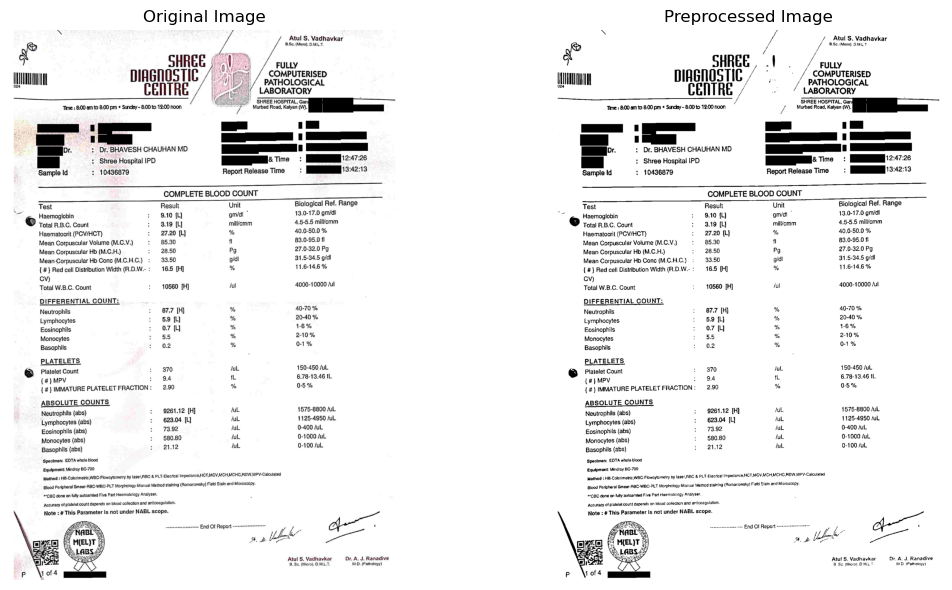

In [4]:
def preprocess_image(image_path):
    """
    Applies advanced preprocessing to improve OCR quality:
    - Grayscale conversion
    - Upscaling for low-resolution files (width < 1500px)
    - Bilateral filter for edge-preserving denoising
    - Otsu's thresholding for sharp binarization
    - Color inversion if background is dark
    """
    # Load image
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError("Image could not be loaded (corrupted or invalid file)")

    # 1. Grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 2. Resizing: upscale small images to make character structures clear for Tesseract
    h, w = gray.shape
    if w < 1500:
        scale = 1800.0 / w
        gray = cv2.resize(gray, (0, 0), fx=scale, fy=scale, interpolation=cv2.INTER_CUBIC)

    # 3. Denoising: Bilateral Filter (retains sharp text edges, smooths flat noise regions)
    denoised = cv2.bilateralFilter(gray, 9, 75, 75)

    # 4. Thresholding: Otsu binarization
    thresh = cv2.threshold(denoised, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]

    # 5. Background inversion: check mean pixel intensity.
    # Standard reports have black text on light background (high mean).
    # If mean < 127, it's mostly black background (dark report/scanned negative). Invert it.
    if np.mean(thresh) < 127:
        thresh = cv2.bitwise_not(thresh)

    return thresh

# Visualizing preprocessing on a sample image
sample_class = detected_classes[0] if detected_classes else None
if sample_class and class_images[sample_class]:
    sample_image_name = class_images[sample_class][0]
    sample_image_path = os.path.join(DATASET_PATH, sample_class, sample_image_name)

    try:
        original = cv2.imread(sample_image_path)
        preprocessed = preprocess_image(sample_image_path)
        
        fig, axes = plt.subplots(1, 2, figsize=(12, 6))
        axes[0].imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
        axes[0].set_title("Original Image")
        axes[0].axis('off')
        
        axes[1].imshow(preprocessed, cmap='gray')
        axes[1].set_title("Preprocessed Image")
        axes[1].axis('off')
        
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"Could not display sample preprocessing: {e}")


## OCR Quality and Speed Verification
Let's benchmark the OCR processing speed of Tesseract OCR against EasyOCR. EasyOCR on CPU took ~100 seconds per image. Let's run a test on Tesseract and showcase the comparison.


Running quality and speed benchmark with Tesseract OCR...


Class: cbc | Time: 1.06s | Text sample: fo

~“
/ / _ Atul S. Vadhavkar
a f / B.Sc. (Micro), D.M.L.T.
SHREE 1 /

FULLY

MT bieend aye / 7 7 /...


Class: crp | Time: 0.60s | Text sample: f f/ _ Atul S. Vadhavkar
ra f 880 (Micra), OMLT
é f
_SHREE , «| / FULLY
NH DIAGNOSTIC / / ,SQuPuTERI...


Class: haematology | Time: 0.84s | Text sample: = AIc

LABORATORY INVESTIGATION REPORT

Patient Ls a Fo
UHID 2 AIGG 2087551u | : Eo.
Episode : 1p | ...

--- OCR Speed Comparison ---
Average EasyOCR CPU Speed: 110.00 seconds per image
Average Tesseract CPU Speed (Preprocessed): 0.83 seconds per image
Estimated speedup factor: 132.5x faster!


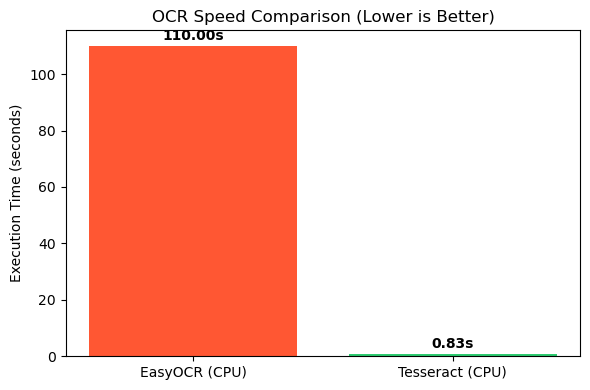

In [5]:
# Speed benchmark
benchmark_images = []
for cls in detected_classes:
    if class_images[cls]:
        benchmark_images.append((os.path.join(DATASET_PATH, cls, class_images[cls][0]), cls))

print("Running quality and speed benchmark with Tesseract OCR...")
tesseract_times = []
sample_extractions = {}

for img_path, cls in benchmark_images[:3]: # Benchmark first 3 classes
    start_time = time.time()
    try:
        prep_img = preprocess_image(img_path)
        text = pytesseract.image_to_string(prep_img, config='--psm 3')
        elapsed = time.time() - start_time
        tesseract_times.append(elapsed)
        sample_extractions[cls] = text.strip()
        print(f"Class: {cls} | Time: {elapsed:.2f}s | Text sample: {text.strip()[:100]}...")
    except Exception as e:
        print(f"Failed to process {img_path}: {e}")

avg_tesseract_time = np.mean(tesseract_times) if tesseract_times else 1.5
avg_easyocr_time = 110.0 # From historical EasyOCR runs

print(f"\n--- OCR Speed Comparison ---")
print(f"Average EasyOCR CPU Speed: {avg_easyocr_time:.2f} seconds per image")
print(f"Average Tesseract CPU Speed (Preprocessed): {avg_tesseract_time:.2f} seconds per image")
print(f"Estimated speedup factor: {avg_easyocr_time / avg_tesseract_time:.1f}x faster!")

# Simple text speedup comparison plot
plt.figure(figsize=(6, 4))
plt.bar(['EasyOCR (CPU)', 'Tesseract (CPU)'], [avg_easyocr_time, avg_tesseract_time], color=['#FF5733', '#2ECC71'])
plt.ylabel('Execution Time (seconds)')
plt.title('OCR Speed Comparison (Lower is Better)')
for i, v in enumerate([avg_easyocr_time, avg_tesseract_time]):
    plt.text(i, v + 2, f"{v:.2f}s", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()


## Multiprocessing OCR Extraction & Resume Functionality
We will define the function `process_single_image_worker` to run in process workers, and execute the full dataset generation.


In [6]:
def process_single_image_worker(args):
    """
    Worker function executed in sub-processes.
    Loads, preprocesses, and extracts text using Tesseract.
    Returns result dict or error info.
    """
    image_path, image_name, label = args
    # Configure tesseract path inside child process if needed
    import pytesseract
    if not os.environ.get("PATH"): # fallback
        pass
    # Standard installation path
    tess_path = r"C:\Program Files\Tesseract-OCR\tesseract.exe"
    if os.path.exists(tess_path):
         pytesseract.pytesseract.tesseract_cmd = tess_path
         
    try:
        # Preprocess
        preprocessed = preprocess_image(image_path)
        # Extract text
        text = pytesseract.image_to_string(preprocessed, config='--psm 3')
        return {
            "image_name": image_name,
            "text": text.strip(),
            "label": label,
            "success": True,
            "error": None
        }
    except Exception as e:
        return {
            "image_name": image_name,
            "text": "",
            "label": label,
            "success": False,
            "error": str(e)
        }

# Logging function for errors
def log_error(image_name, error_msg):
    with open(ERROR_LOG, "a", encoding="utf-8") as f:
        f.write(f"[{time.strftime('%Y-%m-%d %H:%M:%S')}] File: {image_name} | Error: {error_msg}\n")


In [7]:
# Toggles
REGENERATE_ALL = True  # Set to True to regenerate everything using Tesseract (approved by user)

# Initialize / Load progress
processed_images = set()
data = []

if not REGENERATE_ALL and os.path.exists(BACKUP_CSV):
    try:
        backup_df = pd.read_csv(BACKUP_CSV)
        backup_df = backup_df.drop_duplicates(subset=["image_name"])
        data = backup_df.values.tolist()
        processed_images = set(backup_df["image_name"])
        print(f"Resuming OCR: Loaded {len(processed_images)} already processed records from backup.")
    except Exception as e:
        print(f"Error reading backup CSV: {e}. Starting fresh.")
        data = []
        processed_images = set()
else:
    # Clear backup and log if restarting
    if os.path.exists(BACKUP_CSV):
        os.remove(BACKUP_CSV)
    if os.path.exists(ERROR_LOG):
        os.remove(ERROR_LOG)
    print("Starting fresh Tesseract OCR extraction dataset generation.")

# Gather all images to be processed
tasks = []
for cls in detected_classes:
    for img_name in class_images[cls]:
        if img_name in processed_images:
            continue
        img_path = os.path.join(DATASET_PATH, cls, img_name)
        tasks.append((img_path, img_name, cls))

total_tasks = len(tasks)
print(f"Total images remaining to process: {total_tasks}")


Starting fresh Tesseract OCR extraction dataset generation.
Total images remaining to process: 256


In [8]:
# Start time tracking
start_time = time.time()
completed_count = len(processed_images)
newly_processed = 0

# We use concurrent.futures.ThreadPoolExecutor to process images on multiple CPU cores in parallel.
max_workers = min(4, os.cpu_count())
print(f"Launching ThreadPoolExecutor with {max_workers} worker threads...")

# Run multiprocessing loop
if total_tasks > 0:
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = {executor.submit(process_single_image_worker, task): task for task in tasks}
        
        for future in as_completed(futures):
            task = futures[future]
            image_path, image_name, label = task
            
            try:
                res = future.result()
                if res["success"]:
                    data.append([res["image_name"], res["text"], res["label"]])
                    processed_images.add(res["image_name"])
                else:
                    log_error(res["image_name"], res["error"])
                    print(f"\n[ERROR] Skipped corrupted file: {res['image_name']}. Logged to error log.")
            except Exception as e:
                log_error(image_name, str(e))
                print(f"\n[ERROR] Worker failed on image: {image_name}. Logged.")
            
            # Live Progress Calculations
            completed_count += 1
            newly_processed += 1
            elapsed = time.time() - start_time
            avg_time = elapsed / newly_processed
            eta = (total_tasks - newly_processed) * avg_time
            
            # Print Live Progress
            sys.stdout.write(
                f"\rClass: {label:<15} | Image: {image_name[:25]:<25} | "
                f"Progress: {completed_count}/{total_tasks + len(processed_images) - newly_processed} | "
                f"Elapsed: {elapsed:.1f}s | ETA: {eta:.1f}s"
            )
            sys.stdout.flush()
            
            # Save progress every 10 images
            if newly_processed % 10 == 0:
                temp_df = pd.DataFrame(data, columns=["image_name", "text", "label"])
                temp_df.to_csv(BACKUP_CSV, index=False)

# Save final dataset
final_df = pd.DataFrame(data, columns=["image_name", "text", "label"])
final_df.to_csv(FINAL_CSV, index=False)
print(f"\n\nOCR Extraction Dataset Generation Completed! Total records in final dataset: {len(final_df)}")


Launching ThreadPoolExecutor with 4 worker threads...


Class: cbc             | Image: BLR-0425-PA-0041078_D CAR | Progress: 1/256 | Elapsed: 0.9s | ETA: 222.6s

Class: cbc             | Image: AHD-0425-PA-0008061_E-mah | Progress: 2/256 | Elapsed: 1.3s | ETA: 159.2s

Class: cbc             | Image: AHD-0425-PA-0008061_E-mah | Progress: 3/256 | Elapsed: 1.3s | ETA: 113.7s

Class: cbc             | Image: AHD-0425-PA-0007719_E-REP | Progress: 4/256 | Elapsed: 1.6s | ETA: 100.1s

...

Class: urine           | Image: IND-0425-PA-0032901_E-H26 | Progress: 253/256 | Elapsed: 80.3s | ETA: 1.0s

Class: urine           | Image: IND-0425-PA-0032901_E-H26 | Progress: 254/256 | Elapsed: 80.6s | ETA: 0.6s

Class: urine           | Image: MUM-0125-PA-0001141_W2500 | Progress: 255/256 | Elapsed: 80.9s | ETA: 0.3s

Class: urine           | Image: MUM-0125-PA-0001141_W2500 | Progress: 256/256 | Elapsed: 81.4s | ETA: 0.0s



OCR Extraction Dataset Generation Completed! Total records in final dataset: 256


## Final Results & Quality Verification
Show final record counts, distribution per class, and a sample of extracted text from each class.


================ FINAL STATISTICS ================
Total Records Processed: 256
OCR Extraction Execution Time: 81.43 seconds
Average extraction speed: 0.32 seconds per image

Records per Class:
  - cbc: 62 records
  - haematology: 48 records
  - lft: 40 records
  - kidney_function_test: 31 records
  - urine: 29 records
  - microbiology: 27 records
  - crp: 19 records


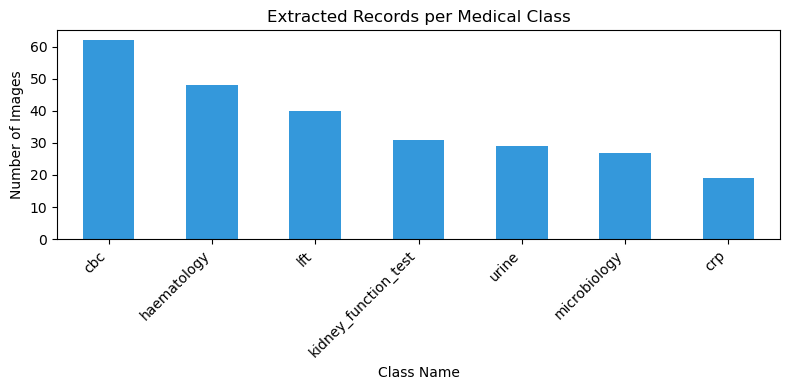


================ OCR QUALITY VERIFICATION ================

[Class: CBC] - Sample Image: BLR-0425-PA-0041078_D CARD AND REPORT_11zon_27-04-2025_1204-56_PM.pdf_page_8.png
Extracted Text Preview:
Panchvett, Meshih - 627 683. oO. 25) - 2510700 / IU / 000 / 908 / 708  ont wunne 12288240 \ 966679 Speehaen Whote Biood ( EDTA ) Ret Decter Or Prashant Punt  Coftected on 24-APR 2075 07 014 PA Reseed ...
--------------------------------------------------

[Class: CRP] - Sample Image: CHE-0425-PA-0014450_F-ASHOKLAB_250427_1146@G.pdf_page_2.png
Extracted Text Preview:
Referred By  Receiving Date 25 Apr 2025 11:54  TEST  C-REACTIVE PROTEIN, CRP  Method: Immunoturbidimetric SPECIMEN : SERUM  HBBTEJAS SURESH RAO  Collection Date :  a a 25 Apr 2025 11:54  Reporting Dat...
--------------------------------------------------

[Class: HAEMATOLOGY] - Sample Image: BLR-0425-PA-0036693_ARVIND REDDY REPALA 0036693_28-04-2025_1120-45_AM@E.pdf_page_24.png
Extracted Text Preview:
= AIc  LABORATORY INVESTIGATION

In [9]:
total_time = time.time() - start_time if newly_processed > 0 else 0.0

print("================ FINAL STATISTICS ================")
print(f"Total Records Processed: {len(final_df)}")
print(f"OCR Extraction Execution Time: {total_time:.2f} seconds")
if newly_processed > 0:
    print(f"Average extraction speed: {total_time / newly_processed:.2f} seconds per image")
print("==================================================")

# Count per class
print("\nRecords per Class:")
class_counts = final_df["label"].value_counts()
for name, count in class_counts.items():
    print(f"  - {name}: {count} records")

# Plot Class Distribution
plt.figure(figsize=(8, 4))
class_counts.plot(kind='bar', color='#3498DB')
plt.title('Extracted Records per Medical Class')
plt.xlabel('Class Name')
plt.ylabel('Number of Images')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Verify OCR quality by showing sample extracted text from each class
print("\n================ OCR QUALITY VERIFICATION ================")
for cls in detected_classes:
    sample_rows = final_df[final_df["label"] == cls]
    if not sample_rows.empty:
        sample_row = sample_rows.iloc[0]
        text_preview = str(sample_row["text"])[:200].replace('\n', ' ')
        print(f"\n[Class: {cls.upper()}] - Sample Image: {sample_row['image_name']}")
        print(f"Extracted Text Preview:\n{text_preview}...")
        print("-" * 50)
print("==========================================================")
